In [49]:
import pandas as pd
import numpy as np
import kagglehub
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2
import dataprep as dp

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
path = kagglehub.dataset_download("konradb/visuelle-complete-dataset")

image_root = Path(path) / 'images'

# Match image path with product code
cols = ['external_code', 'image_path']
paths = pd.concat([
    pd.read_csv('data/train_with_target.csv', usecols=cols).assign(src='train'),
    pd.read_csv('data/test_with_target.csv',  usecols=cols).assign(src='test'),
], ignore_index=True)

In [37]:
# Get the range of sizes from the image set
# Images need to be resized if not uniform
sizes = paths['image_path'].apply(
    lambda p: Image.open(image_root / p).size)

dimensions = pd.DataFrame(sizes.tolist(), columns=['w', 'h'], index=sizes.index)

print(dimensions.describe().loc[['count','min', 'max']])

print(paths['image_path'].apply(lambda p: Image.open(image_root / p).mode).value_counts())


            w       h
count  5577.0  5577.0
min      16.0    20.0
max    1195.0  1200.0
image_path
RGBA    5577
Name: count, dtype: int64


Some images are incredibly small: 16px / 20px, so I need to check how many images have this kind of dimensions so that I can make an informed decision reg removing them. 
ResNet for example takes 224x224, dozens of images scaled from 20x20px will feed poor signal to the model.

Using multiples of 32 to check images sizes using this as reference:
https://discuss.pytorch.org/t/input-image-shape-for-resnet18-architecture/80693

In [42]:
dimensions['short'] = dimensions[['w', 'h']].min(axis=1)

total_less_than_224 = int((dimensions['short'] < 224).sum())
total_less_than_128 = int((dimensions['short'] < 128).sum())
total_less_than_32 = int((dimensions['short'] < 32).sum())

print("No. of imgs with shorter side < 224:", total_less_than_224)
print("No. of imgs with shorter side < 128:", total_less_than_128)
print("No. of imgs with shorter side < 32:", total_less_than_32)

No. of imgs with shorter side < 224: 337
No. of imgs with shorter side < 128: 11
No. of imgs with shorter side < 32: 3


In [47]:
dimensions['ratio'] = dimensions['w'] / dimensions['h']

print(dimensions['ratio'].idxmin())
print(dimensions['ratio'].idxmax())

5089
4286


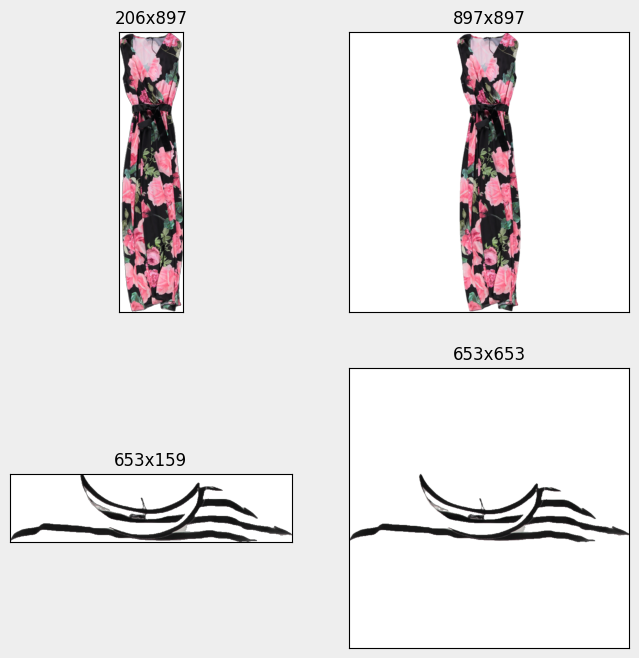

In [ ]:
# Test function to add white padding on the images with the worse ratio
min_max = [dimensions['ratio'].idxmin(), dimensions['ratio'].idxmax()]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
fig.patch.set_facecolor('#EEE')

for row, i in enumerate(min_max):
    img = Image.open(image_root / paths.loc[i, 'image_path'])
    square = dp.make_square(img)
    for ax, image in zip(axes[row], [img, square]):
        ax.imshow(image)
        ax.set_title(f"{image.size[0]}x{image.size[1]}")
        ax.set_xticks([]); ax.set_yticks([])

plt.show()

With roughly ~350 images with width or height below 224px, it would be helpful to know later on which images will be upscaled by ResNet / CLIP.

This number doesn't seem significant enough (?) to cause issues, but the information stays stored just in case. Images that were magnified and therefore might contain noise might end up doing worse than images that had more detail.

In [60]:
image_meta = pd.DataFrame(sizes.tolist(), columns=['w', 'h'], index=paths.index)
image_meta.insert(0, 'external_code', paths['external_code'])
image_meta['low_res'] = image_meta[['w', 'h']].max(axis=1) < 224

image_meta.to_csv('data/image_meta.csv', index=False)